In [4]:
import pandas as pd

In [13]:
!pip install seaborn missingno

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---- ----------------------------------- 3.7/36.6 MB 19.8 MB/s eta 0:00:02
   -------- ------------------------------- 7.3/36.6 MB 18.9 MB/s eta 0:00:02
   ------------ --------------------------- 11.3/36.6 MB 18.5 MB/s eta 0:00:02
   ---------------- ----------------------- 14.9/36.6 MB 18.4 MB/s eta 0:00:02
   -------------------- ------------------- 18.9/36.6 MB 18.3 MB/s eta 0:00:01
   ------------------------ --------------- 22.5/36.6 MB 18.5 MB/s eta 0:00:01
   ---------------------------- ----------- 26.2/36.6 MB 18.5 MB/s eta 0:00:01
   -------------------------------- ------- 29.9/36.6 MB 18.4 MB/s eta 0:00:01
   ------------------------------------ --- 33.8/36.6 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 18.0 MB/s  0:00:02

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   -----------------------------

In [14]:
import seaborn as sns

In [15]:
import missingno as msno

In [8]:
import matplotlib.pyplot as plt

In [11]:
from pathlib import Path

In [12]:
import warnings

In [18]:
warnings.filterwarnings('ignore')

In [21]:
# Set display options for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Bellabeat Data Cleaning Pipeline - Week 1

1. CONFIGURATION - LOCAL PATHS

In [22]:
BASE_PATH = Path(r"E:\Lab Mantix Provided Files\FitabaseData\FitABaseData")
CLEAN_PATH = Path(r"E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data")

In [23]:
# Create cleaned data folder if it doesn't exist
CLEAN_PATH.mkdir(parents=True, exist_ok=True)
print(f"✅ Cleaned data will be saved to: {CLEAN_PATH}")

✅ Cleaned data will be saved to: E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data


In [24]:
# Key files to process (update paths if filenames differ slightly)
KEY_FILES = {
    'dailyActivity': BASE_PATH / 'dailyActivity_merged.csv',
    'sleepDay': BASE_PATH / 'sleepDay_merged.csv', 
    'weightLogInfo': BASE_PATH / 'weightLogInfo_merged.csv',
    'hourlyCalories': BASE_PATH / 'hourlyCalories_merged.csv',
    'hourlySteps': BASE_PATH / 'hourlySteps_merged.csv'
}

print("\n📋 Files to process:")
for name, path in KEY_FILES.items():
    print(f"  {name}: {path}")


📋 Files to process:
  dailyActivity: E:\Lab Mantix Provided Files\FitabaseData\FitABaseData\dailyActivity_merged.csv
  sleepDay: E:\Lab Mantix Provided Files\FitabaseData\FitABaseData\sleepDay_merged.csv
  weightLogInfo: E:\Lab Mantix Provided Files\FitabaseData\FitABaseData\weightLogInfo_merged.csv
  hourlyCalories: E:\Lab Mantix Provided Files\FitabaseData\FitABaseData\hourlyCalories_merged.csv
  hourlySteps: E:\Lab Mantix Provided Files\FitabaseData\FitABaseData\hourlySteps_merged.csv


# HELPER FUNCTIONS

In [25]:
def load_and_validate_csv(file_path, name):
    """Load CSV with comprehensive validation"""
    try:
        df = pd.read_csv(file_path)
        print(f"✅ {name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
        print(f"   Columns: {list(df.columns)}")
        print(f"   Date range: {pd.to_datetime(df.iloc[:,1], errors='coerce').min()} to {pd.to_datetime(df.iloc[:,1], errors='coerce').max()}")
        print(f"   Users: {df.iloc[:,0].nunique()}")
        return df
    except FileNotFoundError:
        print(f"❌ {name} NOT FOUND: {file_path}")
        return None
    except Exception as e:
        print(f"❌ Error loading {name}: {e}")
        return None

In [26]:
def clean_dates(df, date_col):
    """Standardize date formats"""
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])  # Drop invalid dates
    return df

In [35]:
def flag_tracker_issues(df):
    """Flag data quality issues - CORRECTED VERSION"""
    issues = {}  # ✅ This line was missing!
    
    # Full sedentary day = tracker not worn
    if 'SedentaryMinutes' in df.columns:
        df['tracker_not_worn'] = df['SedentaryMinutes'] == 1440
        issues['full_sedentary_days'] = df['tracker_not_worn'].sum()
        print(f"⚠️  Full sedentary days: {issues['full_sedentary_days']:,}")
    
    # Step outliers
    if 'TotalSteps' in df.columns:
        df['steps_outlier'] = df['TotalSteps'] > 30000
        issues['step_outliers'] = df['steps_outlier'].sum()
        print(f"⚠️  Step outliers (>30k): {issues['step_outliers']:,}")
    
    # Zero activity days
    if all(col in df.columns for col in ['TotalSteps', 'TotalDistance']):
        df['zero_activity'] = (df['TotalSteps'] == 0) & (df['TotalDistance'] == 0)
        issues['zero_activity_days'] = df['zero_activity'].sum()
        print(f"⚠️  Zero activity days: {issues['zero_activity_days']:,}")
    
    return issues

# MAIN CLEANING PIPELINE - DAILY DATA

In [30]:
# Load and clean DAILY ACTIVITY (MASTER FILE)
activity_df = load_and_validate_csv(KEY_FILES['dailyActivity'], "Daily Activity")

✅ Daily Activity: 940 rows × 15 cols
   Columns: ['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']
   Date range: 2016-04-12 00:00:00 to 2016-05-12 00:00:00
   Users: 33


In [31]:
# Standardize dates
activity_df = clean_dates(activity_df, 'ActivityDate')
activity_df = activity_df.rename(columns={'ActivityDate': 'activity_date'})

In [36]:
# Flag issues
activity_issues = flag_tracker_issues(activity_df)

⚠️  Full sedentary days: 79
⚠️  Step outliers (>30k): 1
⚠️  Zero activity days: 77


In [37]:
print(f"\n📊 Issues summary: {activity_issues}")


📊 Issues summary: {'full_sedentary_days': np.int64(79), 'step_outliers': np.int64(1), 'zero_activity_days': np.int64(77)}


In [38]:
 # Remove duplicates
initial_rows = len(activity_df)
activity_df = activity_df.drop_duplicates(subset=['Id', 'activity_date'])
print(f"✅ Duplicates removed: {initial_rows - len(activity_df):,} rows")

✅ Duplicates removed: 0 rows


In [44]:
# Remove full sedentary days (tracker not worn)
if 'tracker_not_worn' not in activity_df.columns:
    activity_df['tracker_not_worn'] = activity_df['SedentaryMinutes'] == 1440

In [45]:
clean_activity = activity_df[~activity_df['tracker_not_worn']].copy()

In [46]:
# Now the print statement will work!
print(f"✅ Tracker-not-worn days removed: {len(activity_df) - len(clean_activity):,} rows")
print(f"📊 Clean activity records: {len(clean_activity):,} rows")
print(f"📊 Data quality improved: {len(clean_activity)/len(activity_df)*100:.1f}%")

✅ Tracker-not-worn days removed: 79 rows
📊 Clean activity records: 861 rows
📊 Data quality improved: 91.6%


In [47]:
print(f"📊 Original activity_df: {len(activity_df):,} rows")

📊 Original activity_df: 940 rows


In [48]:
# Remove step outliers
clean_activity = clean_activity[clean_activity['steps_outlier'] == False].copy()
print(f"✅ Step outliers removed: {(activity_df['steps_outlier'] == True).sum():,} rows")

✅ Step outliers removed: 1 rows


In [49]:
# Final cleaned dataset
print(f"🎉 FINAL CLEAN DATASET: {len(clean_activity):,} rows ({len(clean_activity)/len(activity_df)*100:.1f}% of original)")

🎉 FINAL CLEAN DATASET: 860 rows (91.5% of original)


In [50]:
# Quick quality check
print("\n📈 CLEAN DATA SUMMARY:")
print(clean_activity[['TotalSteps', 'SedentaryMinutes', 'Calories']].describe())


📈 CLEAN DATA SUMMARY:
       TotalSteps  SedentaryMinutes  Calories
count      860.00            860.00    860.00
mean      8248.07            949.95   2350.20
std       4691.32            281.04    714.19
min          0.00              0.00     52.00
25%       4824.75            720.00   1851.75
50%       7969.00           1018.50   2205.00
75%      11055.00           1187.25   2828.50
max      29326.00           1439.00   4900.00


# CONTINUE WITH SLEEP DATA CLEANING

In [51]:
print("\n😴 PROCESSING SLEEP DATA...")
sleep_df = pd.read_csv(r"E:\Lab Mantix Provided Files\FitabaseData\FitABaseData\sleepDay_merged.csv")
print(f"✅ Sleep data loaded: {sleep_df.shape[0]:,} rows × {sleep_df.shape[1]} cols")


😴 PROCESSING SLEEP DATA...
✅ Sleep data loaded: 413 rows × 5 cols


In [54]:
sleep_df.columns

Index(['Id', 'activity_date', 'TotalSleepRecords', 'TotalMinutesAsleep',
       'TotalTimeInBed'],
      dtype='str')

In [56]:
# 2. ✅ CHECK COLUMNS FIRST
print("📋 Sleep data columns:", sleep_df.columns.tolist())

📋 Sleep data columns: ['Id', 'activity_date', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']


In [58]:
print(f"👥 Users: {sleep_df['Id'].nunique()}")

👥 Users: 24


In [59]:
# Remove duplicates (just in case)
initial_rows = len(sleep_df)
sleep_df = sleep_df.drop_duplicates(subset=['Id', 'activity_date'])
print(f"✅ Sleep duplicates removed: {initial_rows - len(sleep_df):,} rows")


✅ Sleep duplicates removed: 3 rows


In [61]:
# Quick validation
print(f"😴 Final sleep data: {len(sleep_df):,} rows")
print(f"📅 Date range: {sleep_df['activity_date'].min()} to {sleep_df['activity_date'].max()}")

😴 Final sleep data: 410 rows
📅 Date range: 2016-04-12 00:00:00 to 2016-05-12 00:00:00


# FINAL MASTER TABLE CREATION

In [63]:
print("\n🔗 MERGING: Activity (860 rows) + Sleep (410 rows)")
print("="*50)


🔗 MERGING: Activity (860 rows) + Sleep (410 rows)


In [64]:
# MERGE activity + sleep on Id + activity_date
daily_master = clean_activity.merge(
    sleep_df[['Id', 'activity_date', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']], 
    on=['Id', 'activity_date'], 
    how='left',
    suffixes=('', '_sleep')
)

In [65]:
print(f"📊 Merged table: {len(daily_master):,} rows × {len(daily_master.columns)} cols")
print(f"😴 Sleep coverage: {daily_master['TotalMinutesAsleep'].count() / len(daily_master) * 100:.1f}% of days")

📊 Merged table: 860 rows × 21 cols
😴 Sleep coverage: 47.7% of days


In [66]:
# 2. Add analysis columns
daily_master['weekday'] = daily_master['activity_date'].dt.day_name()
daily_master['weekday_order'] = pd.Categorical(daily_master['weekday'], 
                                             categories=['Monday','Tuesday','Wednesday','Thursday',
                                                       'Friday','Saturday','Sunday'], ordered=True)

In [67]:
# 3. User segmentation (portfolio gold!)
daily_master['avg_daily_steps'] = daily_master.groupby('Id')['TotalSteps'].transform('mean')
daily_master['user_segment'] = pd.cut(daily_master['avg_daily_steps'],
                                     bins=[0, 5000, 7500, 10000, float('inf')],
                                     labels=['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active'])

print(f"👥 User segments: {daily_master['user_segment'].value_counts().to_dict()}")


👥 User segments: {'Moderately Active': 309, 'Very Active': 208, 'Sedentary': 186, 'Lightly Active': 157}


In [68]:
# 4. SAVE ALL FILES
CLEAN_PATH = Path(r"E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data")
daily_master.to_csv(CLEAN_PATH / '04_daily_master_final.csv', index=False)
clean_activity.to_csv(CLEAN_PATH / '01_daily_activity_cleaned.csv', index=False)
sleep_df.to_csv(CLEAN_PATH / '02_sleep_cleaned.csv', index=False)

print(f"\n💾 FILES SAVED:")
print(f"   {CLEAN_PATH / '04_daily_master_final.csv'}")
print(f"   {CLEAN_PATH / '01_daily_activity_cleaned.csv'}")
print(f"   {CLEAN_PATH / '02_sleep_cleaned.csv'}")


💾 FILES SAVED:
   E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data\04_daily_master_final.csv
   E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data\01_daily_activity_cleaned.csv
   E:\Lab Mantix Provided Files\FitabaseData\Cleaned_Data\02_sleep_cleaned.csv


# FINAL VALIDATION CHARTS

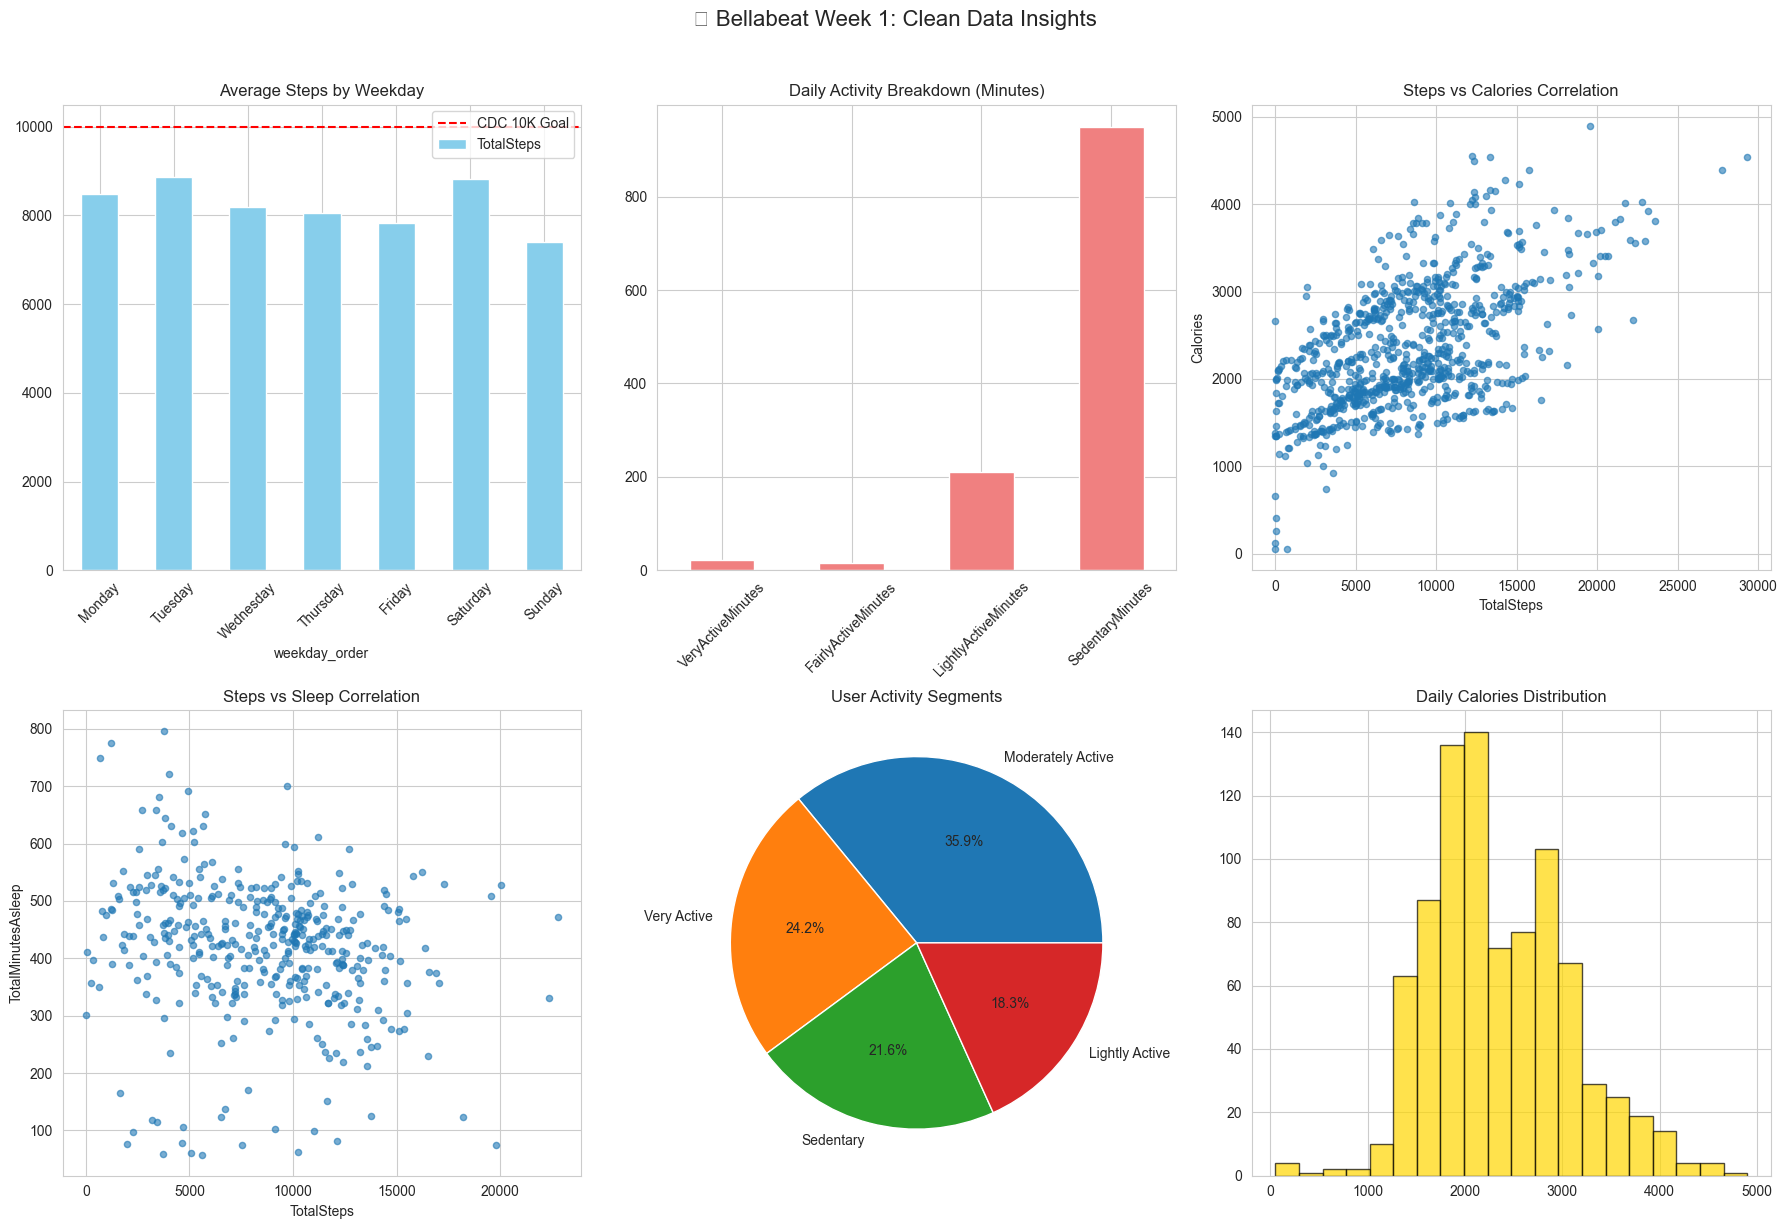

✅ Charts saved: week1_portfolio_charts.png


In [74]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🏆 Bellabeat Week 1: Clean Data Insights', fontsize=16, y=1.02)

# Chart 1: Steps by weekday
weekday_steps = daily_master.groupby('weekday_order')['TotalSteps'].mean()
weekday_steps.plot(kind='bar', ax=axes[0,0], title='Average Steps by Weekday', color='skyblue')
axes[0,0].axhline(10000, color='red', linestyle='--', label='CDC 10K Goal')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# Chart 2: Activity breakdown
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']
means = daily_master[activity_cols].mean()
means.plot(kind='bar', ax=axes[0,1], title='Daily Activity Breakdown (Minutes)', color='lightcoral')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3: Steps vs Calories
daily_master.plot(x='TotalSteps', y='Calories', kind='scatter', ax=axes[0,2], 
                 alpha=0.6, title='Steps vs Calories Correlation')

# Chart 4: Sleep vs Steps
daily_master.plot(x='TotalSteps', y='TotalMinutesAsleep', kind='scatter', 
                 ax=axes[1,0], alpha=0.6, title='Steps vs Sleep Correlation')

# Chart 5: User segments
daily_master['user_segment'].value_counts().plot(kind='pie', ax=axes[1,1], 
                                                autopct='%1.1f%%', title='User Activity Segments')

# Chart 6: Calories distribution
daily_master['Calories'].hist(bins=20, ax=axes[1,2], alpha=0.7, edgecolor='black', color='gold')
axes[1,2].set_title('Daily Calories Distribution')

plt.tight_layout()
plt.savefig(CLEAN_PATH / 'week1_portfolio_charts.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Charts saved: week1_portfolio_charts.png")
